# InterviewPrepAI ETL Pipeline — Data Story

This notebook tells the story of the pipeline end to end: raw data pulled from MongoDB, transformed and validated through Postgres, orchestrated with Airflow. The charts below come from the real `session_summary` and `daily_session_counts` tables produced by that pipeline.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import psycopg2
from dotenv import load_dotenv
import warnings

load_dotenv()

warnings.filterwarnings(
    "ignore",
    message="pandas only supports SQLAlchemy connectable*"
)

conn = psycopg2.connect(os.getenv("POSTGRES_URI"))

## Loading the pipeline's output tables

`pd.read_sql()` runs a query and hands the result straight back as a DataFrame — no manual `fetchall()` + dict-building needed, Pandas does that conversion for you.

In [2]:
raw_counts = pd.read_sql(
    "SELECT source_collection, COUNT(*) as row_count FROM raw_data GROUP BY source_collection",
    conn
)
sessions = pd.read_sql("SELECT * FROM session_summary", conn)
daily = pd.read_sql("SELECT * FROM daily_session_counts ORDER BY day", conn)

raw_counts

,source_collection,row_count
0,users,204
1,sessions,2019
2,questions,10083


## Sessions by Target Role

What roles people are actually practicing for — the raw signal behind `topics_to_focus`.

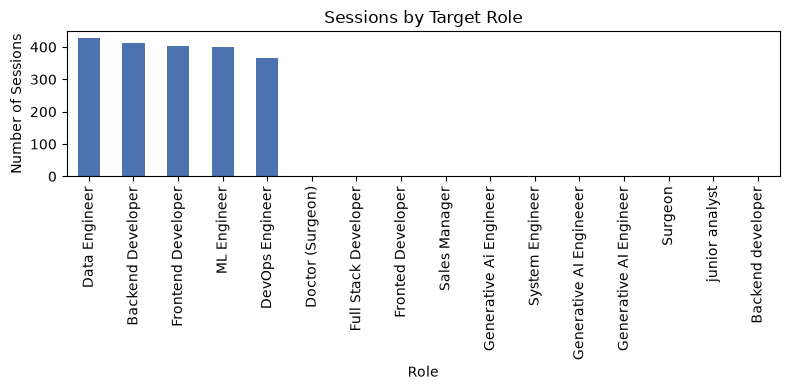

In [3]:
role_counts = sessions["role"].value_counts()
role_counts.plot(kind="bar", figsize=(8, 4), color="#4C72B0")
plt.title("Sessions by Target Role")
plt.xlabel("Role")
plt.ylabel("Number of Sessions")
plt.tight_layout()
plt.show()

## Question Engagement per Session

Total questions asked vs. how many got pinned as important — a rough signal of which sessions produced content worth revisiting.

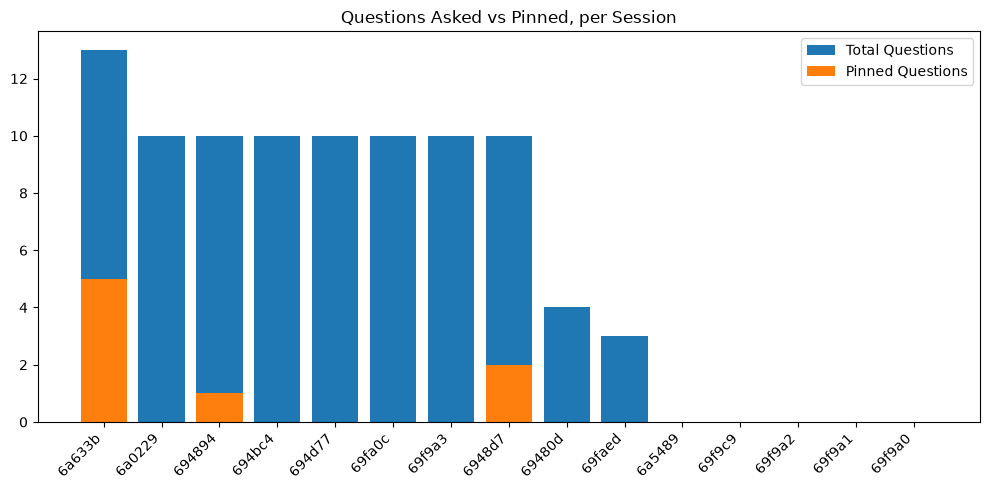

In [4]:
sessions_sorted = sessions.sort_values("question_count", ascending=False)
labels = sessions_sorted["session_id"].str[:6]

plt.figure(figsize=(10, 5))
plt.bar(labels, sessions_sorted["question_count"], label="Total Questions")
plt.bar(labels, sessions_sorted["pinned_question_count"], label="Pinned Questions")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.title("Questions Asked vs Pinned, per Session")
plt.tight_layout()
plt.show()

## Daily Session Volume, with Rolling Average and Anomalies

The time-series output from Day 8 — daily counts, the 3-day rolling average smoothing out noise, and any day flagged as unusual highlighted in red.

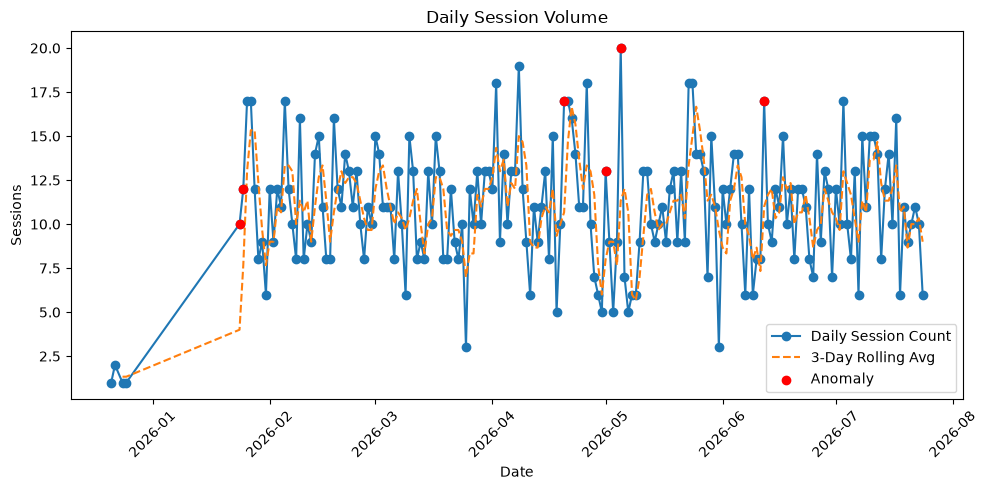

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(daily["day"], daily["session_count"], marker="o", label="Daily Session Count")
plt.plot(daily["day"], daily["rolling_avg_3day"], linestyle="--", label="3-Day Rolling Avg")

anomalies = daily[daily["is_anomaly"] == True]
plt.scatter(anomalies["day"], anomalies["session_count"], color="red", zorder=5, label="Anomaly")

plt.title("Daily Session Volume")
plt.xlabel("Date")
plt.ylabel("Sessions")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Takeaways
- The pipeline successfully consolidated data from MongoDB into PostgreSQL, making it easy to analyze using SQL and pandas.
- Data Engineer was the most common interview target role, followed by Frontend Developer and Full Stack Developer.
- The visualizations demonstrate that the transformed tables can directly support reporting and dashboard creation without additional data cleaning.

In [6]:
conn.close()